# Vol.03: 相関分析
**暗号資産データ分析入門シリーズ**

---

**テーマ**: 複数銘柄間の関係性を定量的に把握する

### なぜ「相関」を知ることが不可欠なのか

暗号資産市場を見ていると、BTCが下がればETHもSOLも下がる、という場面に頻繁に遭遇します。「そんなの当たり前だ」と思うかもしれません。しかし **「なんとなく連動している」という直感と、「相関係数0.80で連動している」という定量的理解の間には、決定的な差** があります。

この差が最も痛烈に表れるのが、**分散投資が機能しない瞬間** です。

「BTC・ETH・SOLに分散投資しているからリスクは3分の1」— これは相関がゼロの場合にのみ成り立つ理論です。現実には暗号資産の主要銘柄は強い正の相関を持っており、市場全体が下落するとき、分散投資していたはずのポートフォリオが一斉に沈みます。分散投資の効果は、自分が思っているほど大きくないかもしれない。それを数値で確認できるのが相関分析です。

### 相関は「定数」ではない

もう一つ重要なのは、**相関は時間とともに変化する** ということです。

平穏な相場では相関が0.6程度だった2銘柄が、暴落時には0.95まで跳ね上がる — これは金融市場でよく観測される現象です。つまり、**最もリスクヘッジが必要な局面で、相関が最も高くなる**。全期間の平均相関だけを見ていると、この危険な性質を完全に見逃します。

このnotebookでは、ローリング相関を使って相関の時間変化を追跡し、「いつ相関が高まるのか」「どの相場環境で連動性が強まるのか」を実際のデータで確認します。

### Vol.04以降への橋渡し

相関分析は「同時点の関係」を見る手法です。しかし市場では、ある銘柄の動きが数分〜数十分遅れて別の銘柄に波及するという「時間差の関係」も存在します。Vol.04（リードラグ分析）では、この同時相関の枠を超えて、時間のずれを伴う関係性に踏み込みます。Vol.03で同時相関の全体像を掴んでおくことが、Vol.04の出発点になります。

### このnotebookで学ぶこと

1. **ピアソン相関係数** — 線形関係の強さを測る
2. **スピアマン順位相関** — 非線形な単調関係を捉える
3. **相関行列とヒートマップ** — 複数銘柄の関係を一覧する
4. **散布図による視覚的確認** — 数値だけでは見えない関係を発見する
5. **ローリング相関** — 相関の時間変化を可視化する
6. **相関の落とし穴** — 疑似相関や非線形関係の注意点
7. **統計的有意性** — 相関係数が偶然でないことを確認する

## 1. 環境準備

In [1]:
!pip install requests pandas numpy matplotlib japanize-matplotlib scipy -q

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy import stats
import time

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print("ライブラリの読み込み完了")

ライブラリの読み込み完了


## 2. データ取得

BTC・ETH・SOLの日足データを取得します。

ここで日足を使う理由は以下のとおりです。

- **ポートフォリオ管理の実務に合う**: リスク管理やリバランスは日次〜週次で行うことが多く、日単位の連動性を把握するのが自然
- **日中のマイクロストラクチャーの影響を避ける**: 1時間足だと、時間帯ごとの流動性の偏りやスプレッドの変動が相関に影響する
- **2年分（約730本）はローリング相関にも十分**: 30日・90日窓のローリング相関を計算しても、十分な期間が確保できる

In [3]:
BINANCE_API_URL = "https://api.binance.com/api/v3/klines"

def fetch_ohlcv(symbol, interval, start_date, end_date, limit=1000):
    """
    Binance REST API から OHLCV データを取得する。

    Parameters
    ----------
    symbol : str     — 銘柄（例: 'BTCUSDT'）
    interval : str   — 時間足（例: '1h', '5m', '1d'）
    start_date : str — 開始日（例: '2024-01-01'）
    end_date : str   — 終了日（例: '2025-01-01'）※この日は含まない
    limit : int      — 1回のリクエストあたりの取得本数（最大1000）

    Returns
    -------
    pd.DataFrame — columns: [open, high, low, close, volume], index: timestamp (UTC)
    """
    start_ts = int(pd.Timestamp(start_date, tz="UTC").timestamp() * 1000)
    end_ts = int(pd.Timestamp(end_date, tz="UTC").timestamp() * 1000)

    all_data = []
    current_ts = start_ts

    while current_ts < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_ts,
            "endTime": end_ts - 1,  # endTime は inclusive なので -1
            "limit": limit,
        }
        resp = requests.get(BINANCE_API_URL, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_data.extend(data)
        current_ts = data[-1][0] + 1  # 最後のレコードの次から再開
        time.sleep(0.2)  # レートリミット遵守（200ms間隔）

    if not all_data:
        return pd.DataFrame(columns=["open", "high", "low", "close", "volume"])

    df = pd.DataFrame(all_data, columns=[
        "timestamp", "open", "high", "low", "close", "volume",
        "_close_time", "_quote_vol", "_trades", "_taker_buy_vol",
        "_taker_buy_quote", "_ignore",
    ])

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)

    df = df[["timestamp", "open", "high", "low", "close", "volume"]]
    df = df.set_index("timestamp").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    return df

# 取得設定
symbols = ['BTC/USDT', 'ETH/USDT', 'SOL/USDT']
since_date = '2023-01-01'
until_date = '2025-01-01'

# 日足データの取得（2年分 → ローリング相関の分析に十分なサンプル数）
data_1d = {}
for sym in symbols:
    api_sym = sym.replace("/", "")
    print(f"取得中: {sym} (1d)...", end=" ")
    data_1d[sym] = fetch_ohlcv(api_sym, '1d', since_date, until_date)
    print(f"{len(data_1d[sym]):,} 本")

# リターンのDataFrameを作成（銘柄をカラムに並べる）
returns_1d = pd.DataFrame({
    sym.replace('/USDT', ''): data_1d[sym]['close'].pct_change()
    for sym in symbols
}).dropna()

print(f"\nリターンデータ: {len(returns_1d)} 日分")
returns_1d.head()

取得中: BTC/USDT (1d)... 

731 本
取得中: ETH/USDT (1d)... 

731 本
取得中: SOL/USDT (1d)... 

731 本

リターンデータ: 730 日分


,BTC,ETH,SOL
timestamp,,,
2023-01-02 00:00:00+00:00,0.003377,0.011380,0.129129
2023-01-03 00:00:00+00:00,0.000139,0.000453,0.185284
2023-01-04 00:00:00+00:00,0.010505,0.034869,0.004488
2023-01-05 00:00:00+00:00,-0.001098,-0.004503,0.000000
2023-01-06 00:00:00+00:00,0.007058,0.014306,0.005212


## 3. ピアソン相関係数とスピアマン順位相関係数

### ピアソン相関係数

2つの変数の**線形関係**の強さを −1 〜 +1 で表す指標です。

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

| 値の範囲 | 解釈 |
|---------|------|
| +0.7 〜 +1.0 | 強い正の相関 |
| +0.4 〜 +0.7 | 中程度の正の相関 |
| -0.4 〜 +0.4 | 弱い相関 |
| -0.7 〜 -0.4 | 中程度の負の相関 |
| -1.0 〜 -0.7 | 強い負の相関 |

**ピアソン相関が捉えるもの・捉えないもの:**

- 「Xが1増えるとYも一定量増える」という**直線的な関係**を測定する
- U字型の関係（Xが極端に大きくても小さくてもYが大きくなる）は検出できない → r ≈ 0 になる
- 外れ値の影響を強く受ける。少数の極端なデータポイントが相関係数を大きく歪めることがある

**金融データでの注意点:**

Vol.02 で確認したとおり、暗号資産のリターンにはファットテール（極端な値の頻出）があります。
暴落時にBTCもETHも大きく下がる — このような極端な同時変動は、ピアソン相関を実態以上に押し上げることがあります。
後のセクションで、外れ値を除外した場合に相関がどう変わるかを確認します。

### スピアマン順位相関係数

データの値そのものではなく、**順位（ランク）に変換してから**ピアソン相関を計算する方法です。

```
元のデータ:  [100, 5, 300, 50]  → 順位: [3, 1, 4, 2]
```

**ピアソンとの違い:**

| | ピアソン | スピアマン |
|---|---|---|
| 測定する関係 | 線形関係 | 単調関係（線形でなくてもOK） |
| 外れ値の影響 | 大きい | 小さい（順位に変換するため） |
| 「Xが増えるとYも増える」 | 直線的なら検出 | 曲線的でも検出 |
| 計算コスト | 低い | やや高い（順位変換が必要） |

**スピアマンが有効な場面:**

- 「BTCのリターンが大きい日ほどETHのリターンも大きい」という**順序の一致度**を見たいとき
- 外れ値の影響を受けにくい相関を知りたいとき
- 関係が直線ではなく、緩やかな曲線状の場合

**両者を比較する意味:**

ピアソンとスピアマンの差が大きい場合、以下の可能性があります。

1. **外れ値がピアソン相関を歪めている** — 少数の極端な共変動がピアソンを押し上げ/押し下げている
2. **非線形の単調関係がある** — 直線ではないが、一方が増えると他方も増える関係

この差を見ることで、「相関係数の数字をどこまで信じてよいか」の判断材料が得られます。

### その前に: 「価格の相関」と「リターンの相関」は別物

相関分析に入る前に、**初学者が最も陥りやすい落とし穴**を先に確認しておきます。

「BTCとETHの価格の相関が0.98だから、非常に強く連動している」— これは**見せかけの相関（spurious correlation）** です。

BTC・ETH・SOLの価格はいずれも長期的に上昇トレンドにあります。
上昇トレンド同士を比較すれば、**中身に関係なく**相関は1に近づきます。
極端な話、BTC価格と世界のインターネット利用者数の相関も高くなりますが、それに意味はありません。

**相関分析を行う際は、価格（水準）ではなくリターン（変化率）を使う**のが鉄則です。
リターンに変換することで非定常なトレンドが除去され、「同じタイミングで同じ方向に動くか」という本来の連動性が見えるようになります。

以下で実際に比較してみましょう。

/tmp/ipykernel_79428/3505561298.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


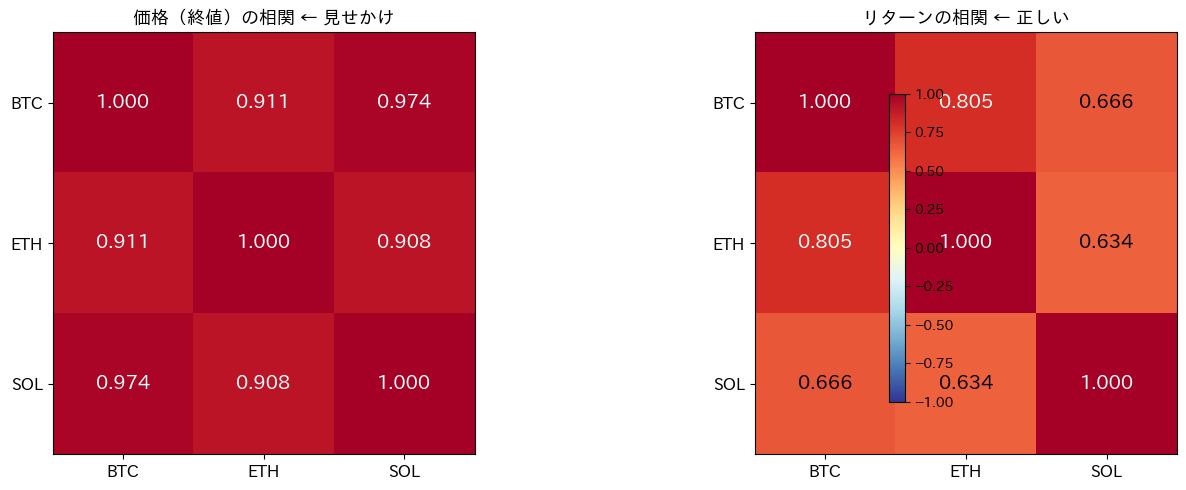

価格の相関は0.9超ですが、これは「共通の上昇トレンド」を反映しているだけです。
リターンの相関は、トレンドを除去した「真の連動性」を表しています。

以降のセクションでは、すべてリターンの相関を使って分析を進めます。


In [4]:
# 価格の相関 vs リターンの相関を比較する

# 価格（終値）のDataFrame
prices_1d = pd.DataFrame({
    sym.replace('/USDT', ''): data_1d[sym]['close']
    for sym in symbols
}).dropna()

# 価格の相関行列
price_corr = prices_1d.corr()

# リターンの相関行列（既に計算済みの returns_1d を使用）
return_corr = returns_1d.corr()

# 並べて表示
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr, title in [
    (axes[0], price_corr, "価格（終値）の相関 ← 見せかけ"),
    (axes[1], return_corr, "リターンの相関 ← 正しい"),
]:
    im = ax.imshow(corr.values, cmap="RdYlBu_r", vmin=-1, vmax=1, aspect="equal")
    ax.set_xticks(range(len(corr)))
    ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, fontsize=12)
    ax.set_yticklabels(corr.index, fontsize=12)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i, j]:.3f}", ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if abs(corr.iloc[i, j]) > 0.7 else "black")
    ax.set_title(title, fontsize=13)

plt.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

print("価格の相関は0.9超ですが、これは「共通の上昇トレンド」を反映しているだけです。")
print("リターンの相関は、トレンドを除去した「真の連動性」を表しています。")
print("\n以降のセクションでは、すべてリターンの相関を使って分析を進めます。")

In [5]:
# ピアソン相関とスピアマン相関の計算
pearson_corr = returns_1d.corr(method='pearson')
spearman_corr = returns_1d.corr(method='spearman')
diff = spearman_corr - pearson_corr

# 3つの相関行列を横並びで比較できるDataFrameを作成
# 対角線（自分自身との相関=1）を除いた上三角部分のペアのみ抽出
pairs = [('BTC', 'ETH'), ('BTC', 'SOL'), ('ETH', 'SOL')]

comparison = pd.DataFrame({
    'ピアソン': [pearson_corr.loc[a, b] for a, b in pairs],
    'スピアマン': [spearman_corr.loc[a, b] for a, b in pairs],
    '差分（スピアマン−ピアソン）': [diff.loc[a, b] for a, b in pairs],
}, index=[f'{a} - {b}' for a, b in pairs])
comparison.index.name = 'ペア'

print("=== ピアソン相関 vs スピアマン相関 ===\n")
display(comparison.round(4))

print("\n差分の解釈:")
print("  差がほぼゼロ → 関係は概ね線形で、外れ値の影響も小さい")
print("  差がプラス   → 外れ値がピアソンを押し下げている、または非線形の単調関係がある")
print("  差がマイナス → 外れ値がピアソンを押し上げている（極端な共変動の影響）")

=== ピアソン相関 vs スピアマン相関 ===



,ピアソン,スピアマン,差分（スピアマン−ピアソン）
ペア,,,
BTC - ETH,0.8050,0.7960,-0.0090
BTC - SOL,0.6662,0.6966,0.0304
ETH - SOL,0.6338,0.6756,0.0418



差分の解釈:
  差がほぼゼロ → 関係は概ね線形で、外れ値の影響も小さい
  差がプラス   → 外れ値がピアソンを押し下げている、または非線形の単調関係がある
  差がマイナス → 外れ値がピアソンを押し上げている（極端な共変動の影響）


## 4. 相関行列とヒートマップ

相関行列をヒートマップで可視化すると、複数銘柄間の関係を一目で把握できます。

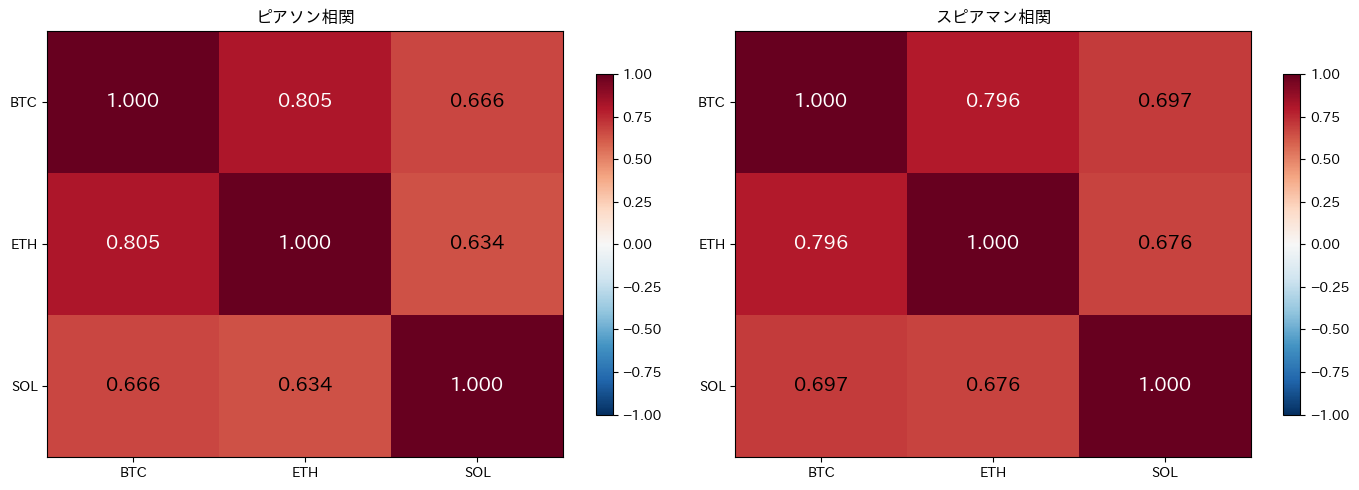

In [6]:
# 相関行列のヒートマップ（matplotlibで作成）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, corr_matrix) in zip(axes, [('ピアソン相関', pearson_corr), ('スピアマン相関', spearman_corr)]):
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

    # 数値をセルに表示
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            val = corr_matrix.iloc[i, j]
            color = 'white' if abs(val) > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=14)

    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_xticklabels(corr_matrix.columns)
    ax.set_yticklabels(corr_matrix.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

## 5. 散布図による視覚的確認

### なぜ相関係数だけでは不十分なのか

相関係数は関係の「強さ」を1つの数値に要約してくれますが、**関係の「形」は教えてくれません**。

有名な例として **アンスコムの四重奏**（Anscombe's quartet）があります。これは、まったく異なる形のデータ（直線、曲線、外れ値1点だけで相関が出ているケースなど）が、すべて同じ相関係数 r = 0.816 を持つという例です。数値だけ見ていると、これらの違いに気づけません。

散布図を描くことで初めてわかることがあります。

- データの分布が**直線的か、曲線的か、クラスターがあるか**
- **外れ値**が相関係数を歪めていないか（セクション6で数値的に確認したが、視覚的にも確認する）
- 特定の領域（例: 暴落時）に**データが偏っていないか**

相関係数を計算したら、必ず散布図も描く。これはデータ分析において「数値を鵜呑みにしない」ための基本的な習慣です。

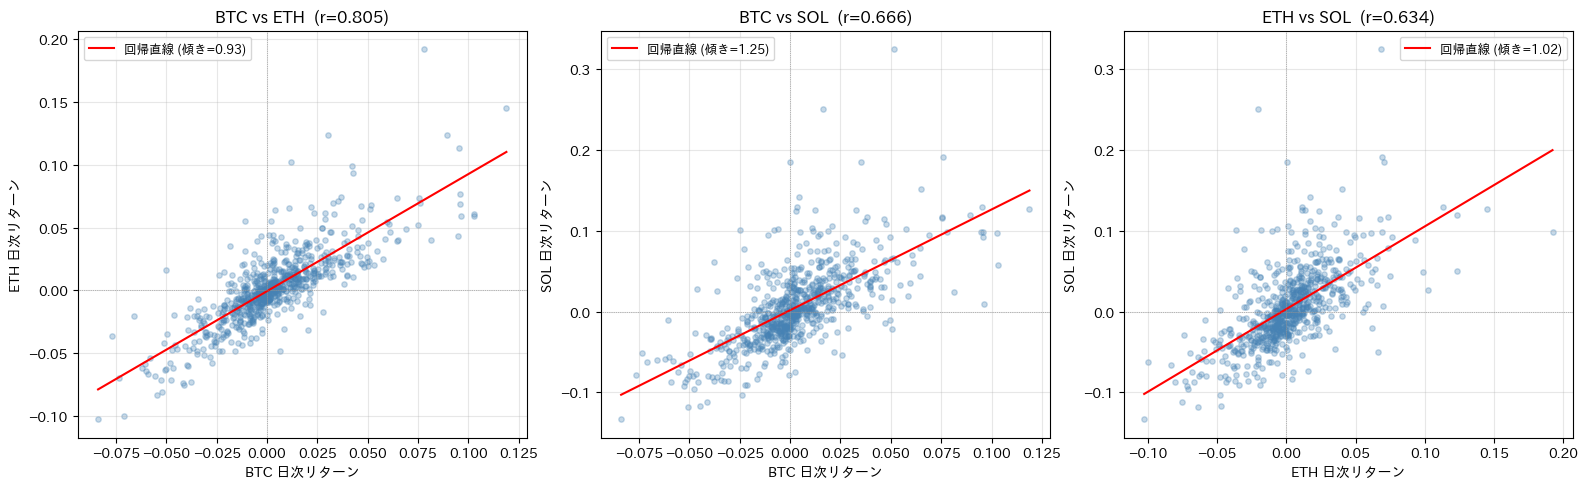

In [7]:
# 銘柄ペアごとの散布図
pairs = [('BTC', 'ETH'), ('BTC', 'SOL'), ('ETH', 'SOL')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (sym1, sym2) in zip(axes, pairs):
    x = returns_1d[sym1]
    y = returns_1d[sym2]

    ax.scatter(x, y, alpha=0.3, s=15, color='steelblue')

    # 回帰直線を追加
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5,
            label=f'回帰直線 (傾き={slope:.2f})')

    r = pearson_corr.loc[sym1, sym2]
    ax.set_title(f'{sym1} vs {sym2}  (r={r:.3f})')
    ax.set_xlabel(f'{sym1} 日次リターン')
    ax.set_ylabel(f'{sym2} 日次リターン')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ゼロラインを追加
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
    ax.axvline(x=0, color='gray', linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.show()

### 回帰直線の傾き（ベータ）の読み方

散布図に描かれた赤い直線は**回帰直線**で、その傾きを**ベータ（β）** と呼びます。

#### ベータが教えてくれること

ベータは「Xが1%動いたとき、Yは何%動くか」を意味します。

| ベータの値 | 意味 | 例 |
|-----------|------|-----|
| β = 1.2 | Xが1%上がるとYは1.2%上がる（**増幅**して連動） | BTCが下がるとETHはもっと下がる |
| β = 1.0 | Xが1%上がるとYも1%上がる（**同じ幅**で連動） | |
| β = 0.7 | Xが1%上がるとYは0.7%上がる（**減衰**して連動） | |

#### 相関係数（r）とベータ（β）の違い

この2つはよく混同されますが、測っているものが違います。

- **相関係数 r** → 関係の**強さ**（どれくらいきれいに直線に乗るか）
- **ベータ β** → 関係の**大きさ**（直線の傾き。何倍動くか）

両者の関係は以下の式で表されます。

$$\beta = r \times \frac{\sigma_Y}{\sigma_X}$$

つまり、ベータは「相関の強さ × ボラティリティの比」です。
相関が同じでも、Yの方がボラティリティが高ければベータは大きくなります。

#### 具体例で考える

たとえば BTC vs ETH の散布図で「傾き = 1.20」「r = 0.80」だった場合:

- **r = 0.80**: BTCとETHの日次リターンはかなり強く連動している
- **β = 1.20**: BTCが1%動くと、ETHは平均して1.2%動く。ETHの方が振れ幅が大きい

これはリスク管理の観点で重要です。「ETHはBTCと連動しているから同じくらいのリスクだろう」と思っていると、実際にはBTCより大きく動くことを見落とします。

## 6. ローリング相関（時間変化する相関）

相関は常に一定ではありません。市場環境によって強くなったり弱くなったりします。
**ローリング相関** は、一定のウィンドウ（期間）を滑らせながら相関を計算することで、
相関の時間変化を可視化する方法です。

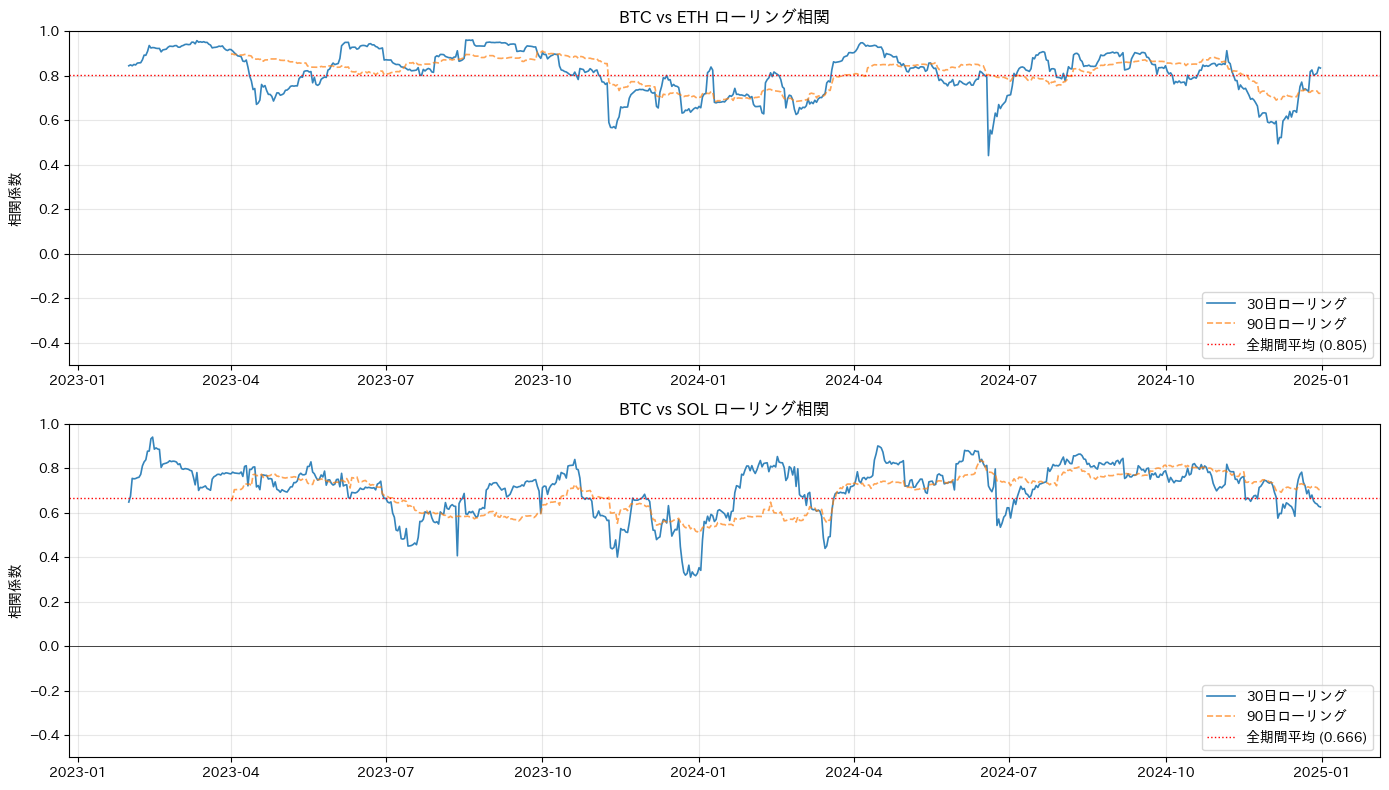

注目ポイント:
  - 相関は常に一定ではなく、時期によって大きく変動する
  - 30日窓はノイジー、90日窓はなめらかだが遅行する → 目的に応じて選択


In [8]:
# ローリング相関の計算（30日・90日ウィンドウ）
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
pairs = [('BTC', 'ETH'), ('BTC', 'SOL')]

for ax, (sym1, sym2) in zip(axes, pairs):
    for window, ls, alpha in [(30, '-', 0.9), (90, '--', 0.7)]:
        rolling_corr = returns_1d[sym1].rolling(window=window).corr(returns_1d[sym2])
        ax.plot(rolling_corr.index, rolling_corr, linestyle=ls, alpha=alpha,
                label=f'{window}日ローリング', linewidth=1.2)

    ax.set_title(f'{sym1} vs {sym2} ローリング相関')
    ax.set_ylabel('相関係数')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=pearson_corr.loc[sym1, sym2], color='red', linewidth=1,
               linestyle=':', label=f'全期間平均 ({pearson_corr.loc[sym1, sym2]:.3f})')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 1.0)

plt.tight_layout()
plt.show()

print("注目ポイント:")
print("  - 相関は常に一定ではなく、時期によって大きく変動する")
print("  - 30日窓はノイジー、90日窓はなめらかだが遅行する → 目的に応じて選択")

## 7. 相関の落とし穴

相関係数を解釈する際に注意すべきポイントをいくつか確認します。

### (1) 相関は因果関係を意味しない
「BTC↑ → ETH↑」という因果関係があるかどうかは、相関だけでは判断できません。

### (2) 外れ値の影響
少数の極端な値が相関係数を大きく歪めることがあります。

### (3) 非線形関係
相関係数（ピアソン）は線形関係しか捉えません。U字型のような関係は見逃します。

In [9]:
# 外れ値の影響を確認する（ペア単位でトリミング）
# ペアごとに上下1%を除外し、相関の変化を比較する

rows = []
for sym1, sym2 in [('BTC', 'ETH'), ('BTC', 'SOL'), ('ETH', 'SOL')]:
    pair_df = returns_1d[[sym1, sym2]].copy()

    # ペアの各列について上下1%を除外
    for col in [sym1, sym2]:
        q_low = pair_df[col].quantile(0.01)
        q_high = pair_df[col].quantile(0.99)
        mask = (pair_df[col] >= q_low) & (pair_df[col] <= q_high)
        pair_df = pair_df[mask]

    corr_full = returns_1d[sym1].corr(returns_1d[sym2])
    corr_trimmed = pair_df[sym1].corr(pair_df[sym2])

    rows.append({
        'ペア': f'{sym1} - {sym2}',
        '全データ': corr_full,
        '上下1%除外': corr_trimmed,
        '差分': corr_trimmed - corr_full,
    })

trimmed_df = pd.DataFrame(rows).set_index('ペア')

print("=== 外れ値除外前後の相関比較 ===\n")
display(trimmed_df.round(4))

print("\n解釈:")
print("  差分がマイナス → 極端な同時変動が相関を押し上げていた（外れ値を除くと相関が下がる）")
print("  差分がほぼゼロ → 外れ値の影響は限定的")
print("\n  ※ ペアごとに各列の上下1%を除外しているため、他銘柄の外れ値の影響を排除しています")

=== 外れ値除外前後の相関比較 ===



,全データ,上下1%除外,差分
ペア,,,
BTC - ETH,0.8050,0.7671,-0.0379
BTC - SOL,0.6662,0.6568,-0.0095
ETH - SOL,0.6338,0.6121,-0.0217



解釈:
  差分がマイナス → 極端な同時変動が相関を押し上げていた（外れ値を除くと相関が下がる）
  差分がほぼゼロ → 外れ値の影響は限定的

  ※ ペアごとに各列の上下1%を除外しているため、他銘柄の外れ値の影響を排除しています


## 8. 相関係数の統計的有意性（p値）

観測された相関が**偶然ではない**ことを確認するため、統計的有意性検定を行います。

- **帰無仮説**: 母相関係数 = 0（真の相関はない）
- **p値**: 帰無仮説が正しい場合に、観測された相関以上の値が偶然得られる確率
- **p < 0.05** なら、5%水準で統計的に有意（偶然とは考えにくい）

In [10]:
# 全ペアの相関係数とp値を計算
rows = []
for sym1, sym2 in [('BTC', 'ETH'), ('BTC', 'SOL'), ('ETH', 'SOL')]:
    x = returns_1d[sym1].values
    y = returns_1d[sym2].values
    r, p_value = stats.pearsonr(x, y)
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "n.s."
    rows.append({
        'ペア': f'{sym1} - {sym2}',
        'Pearson r': r,
        'p値': p_value,
        '有意性': sig,
    })

pval_df = pd.DataFrame(rows).set_index('ペア')

print(f"=== 相関係数の統計的有意性検定（サンプル数: {len(returns_1d)} 日）===\n")
display(pval_df)
print("\n有意水準: *** p<0.001  ** p<0.01  * p<0.05  n.s. 有意でない")

=== 相関係数の統計的有意性検定（サンプル数: 730 日）===



,Pearson r,p値,有意性
ペア,,,
BTC - ETH,0.805044,2.902471e-167,***
BTC - SOL,0.666221,7.871198e-95,***
ETH - SOL,0.633800,2.921529e-83,***



有意水準: *** p<0.001  ** p<0.01  * p<0.05  n.s. 有意でない


### p値の解釈における注意点

上の結果では全ペアが p < 10⁻⁸⁰ という極端に小さなp値を示しています。しかし、この数値を額面どおりに受け取るべきではありません。

**注意1: 統計的有意性 ≠ 実務的な重要性**

サンプルサイズが大きいと、実質的に無意味なほど小さな相関でもp値は限りなくゼロに近づきます。例えば相関係数 r = 0.05（ほぼ無関係）でも、サンプル数が10,000あれば p < 0.001 になります。p値が小さいことは「相関がゼロではない」ことを示しているだけであり、「相関が強い」「実用的に意味がある」ことは保証しません。相関の強さは相関係数の値そのもの（r = 0.80 なのか r = 0.05 なのか）で判断すべきです。

**注意2: 検定の前提が金融データでは成り立たない**

`scipy.stats.pearsonr` のp値は、以下を仮定して計算されています。

- データが**正規分布**に従う
- データポイントが**互いに独立**である

Vol.02 で確認したとおり、暗号資産のリターンはファットテール分布であり正規分布ではありません。また、ボラティリティ・クラスタリング（大きな変動の後に大きな変動が続く）があるため、独立性の仮定も成り立ちません。

これらの前提違反により、p値は実際よりも**楽観的（小さすぎる方向）**にバイアスする可能性があります。

**注意3: ではp値は無意味なのか？**

無意味ではありませんが、使い方を限定すべきです。

- **使えるケース**: 「相関がゼロかどうか」の大まかなスクリーニング（多数のペアから候補を絞り込む場合など）
- **使えないケース**: p値の微細な差（p = 0.03 vs p = 0.07）に基づく判断
- **より適切な方法**: Vol.10 で学ぶブートストラップ法は、分布の仮定を置かずに信頼区間を推定できるため、金融データに適しています

## 9. 相場環境別の相関

上昇相場と下落相場で相関の強さが異なるかどうかを確認します。

ここでは BTC の日次リターンの正負で相場環境を分類します。

**注意**: BTC 自体のリターンで分類しているため、BTC を含むペア（BTC-ETH、BTC-SOL）の
相関は条件付けの影響を機械的に受けます。
**ETH-SOL のペア**（BTC を含まない）が、この分析で最も素直に解釈できるペアです。

BTC上昇日: 375 日 / BTC下落日: 355 日


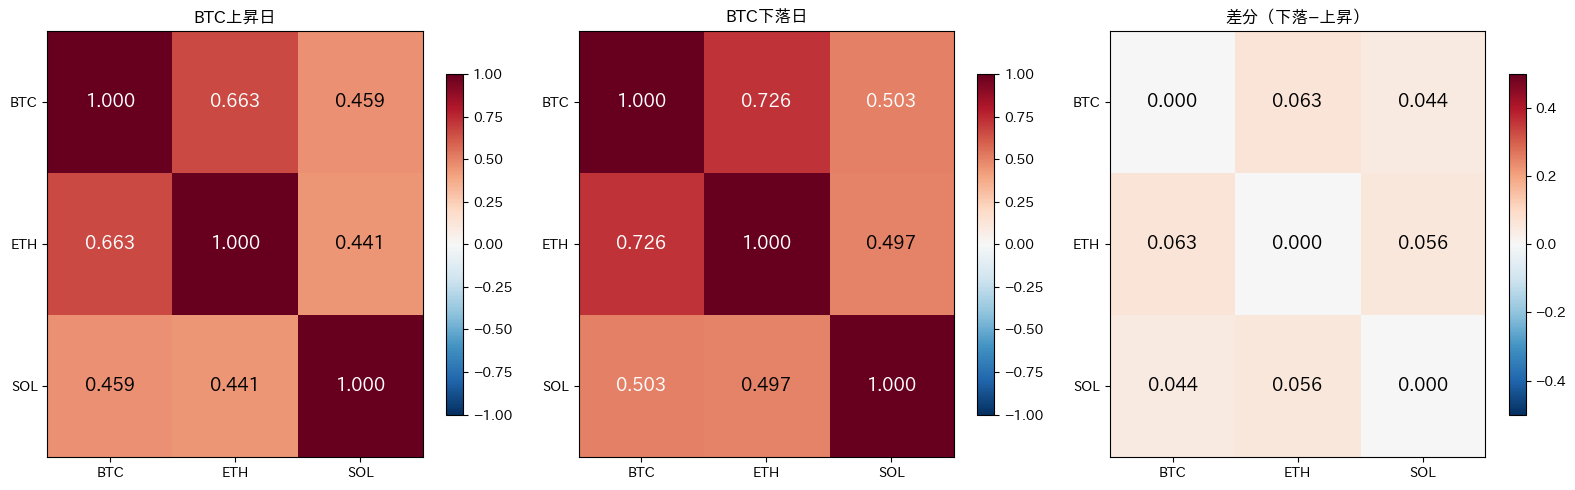

差分がプラス → 下落時に相関が強まる（＝一緒に下落しやすい）
差分がマイナス → 上昇時に相関が強い


In [11]:
# 相場環境を分類（BTCの日次リターンで判定）
btc_ret = returns_1d['BTC']
up_days = returns_1d[btc_ret > 0]     # BTC上昇日
down_days = returns_1d[btc_ret < 0]   # BTC下落日

print(f"BTC上昇日: {len(up_days)} 日 / BTC下落日: {len(down_days)} 日")

# 環境別のピアソン相関
corr_up = up_days.corr(method='pearson')
corr_down = down_days.corr(method='pearson')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ヒートマップ形式で表示
for ax, (title, corr) in zip(axes, [('BTC上昇日', corr_up), ('BTC下落日', corr_down),
                                      ('差分（下落−上昇）', corr_down - corr_up)]):
    vmin, vmax = (-1, 1) if '差分' not in title else (-0.5, 0.5)
    cmap = 'RdBu_r'
    im = ax.imshow(corr.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    for i in range(len(corr)):
        for j in range(len(corr)):
            val = corr.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=color, fontsize=13)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns)
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

print("差分がプラス → 下落時に相関が強まる（＝一緒に下落しやすい）")
print("差分がマイナス → 上昇時に相関が強い")

## 10. まとめ

このnotebookでは、暗号資産の**相関分析**を学びました。

### 学んだこと

| テーマ | 内容 | ポイント |
|--------|------|---------|
| ピアソン相関 | 線形関係の強さを −1〜+1 で測定 | 外れ値に敏感 |
| スピアマン相関 | 順位変換で単調関係を検出 | 外れ値に頑健 |
| ヒートマップ | 相関行列を色で可視化 | 多数の銘柄間の関係を一目で把握 |
| 散布図 | ペアごとの関係を視覚的に確認 | 相関係数だけでは見えない構造（外れ値、非線形）を発見する |
| ローリング相関 | ウィンドウで相関の時間変化を追跡 | ウィンドウ幅はノイズと遅行のトレードオフ |
| 落とし穴 | 疑似相関、外れ値、非線形 | 数値を鵜呑みにせず散布図で確認する習慣が重要 |
| p値 | 相関の統計的有意性を検定 | 有意性と実務的重要性は別 |
| 環境別相関 | 上昇/下落で相関の強さが異なる | 下落時に相関が高まる傾向あり |

### 次のステップ

**Vol.04: リードラグ分析** では、「BTC→ETH」のような先行・遅行関係を時間のずれ（ラグ）を使って検証します。

## 分析結果から分かったこと

### 相関の全体像
- BTC-ETH間のピアソン相関は **0.805** で強い正の相関。BTC-SOLは **0.666**、ETH-SOLは **0.634** と中〜強程度
- 暗号資産の主要銘柄は互いに連動して動く傾向が強い。分散投資効果は限定的
- 全ペアの相関が統計的に非常に有意（p < 10⁻⁸³）

### ピアソンとスピアマンの差
- ピアソンとスピアマンの差は小さく（最大0.04）、主な関係は概ね線形的
- SOLを含むペアで差がやや大きく、外れ値の影響がやや見られる

### 外れ値の影響
- 上下1%を除外すると全ペアで相関がやや低下（最大 -0.038）
- 極端な変動時に一緒に動くことで相関が押し上げられていることを示唆

### ローリング相関の変動
- 30日ローリング相関は±0.3程度変動しており、相関は安定していない
- 「全期間の相関が0.8」でも、特定の時期には0.5を下回ることがある

### 相場環境別の相関
- ETH-SOL（BTC条件付けの影響を受けないペア）で下落日と上昇日の相関差を確認すると、市場環境による相関の非対称性が観測された